# General Setup

In [ ]:
needed_iso3 = [
    'AFG','ARG','AUS','BGD','BRA','BRN','CAN','CHN','COL','CUB','DEU','DOM','ECU','EGY','ERI','ESP','ETH','FRA','GBR',
    'GHA','GRC','GTM','GUY','HKG','HND','HTI','IDN','IND','IRL','IRN','IRQ','ISR','ITA','JAM','JPN','KEN','KHM','KOR',
    'LAO','LBN','LKA','MEX','MMR','MYS','NGA','NIC','NPL','NZL','PAK','PAN','PER','PHL','POL','PRI','PRT','PSE','ROU',
    'RUS','SAU','SDN','SGP','SLV','SOM','SYR','THA','TLS','TTO','TUR','UKR','USA','VEN','VNM','YEM'
]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Ethnic Dataset**

## Setup

In [ ]:
import pandas as pd
import numpy as np

ethnic = pd.read_csv("/content/drive/MyDrive/FYP/data/processed/ethnic_composition_clean.csv")
# Filter required countries first
ethnic = ethnic[ethnic["iso3"].isin(needed_iso3)]
print(ethnic.shape)
ethnic

(5105, 12)


,iso3,country,year,ethnic_group,sex,value,metric,unit,source,source_year,record_type,reliability
75,ARG,Argentina,2022,African,Both Sexes,229472,ethnic_composition,persons,UNdata_Export_20250416_063435193,2024,Census - de jure - complete tabulation,"Final figure, complete"
76,ARG,Argentina,2022,Indigenous,Both Sexes,1306730,ethnic_composition,persons,UNdata_Export_20250416_063435193,2024,Census - de jure - complete tabulation,"Final figure, complete"
77,ARG,Argentina,2022,Not Stated,Both Sexes,44082585,ethnic_composition,persons,UNdata_Export_20250416_063435193,2024,Census - de jure - complete tabulation,"Final figure, complete"
146,AUS,Australia,2001,Afgan,Both Sexes,12408,ethnic_composition,persons,UNdata_Export_20250416_063435193,2009,Census - de jure - complete tabulation,"Final figure, complete"
147,AUS,Australia,2001,African American,Both Sexes,1201,ethnic_composition,persons,UNdata_Export_20250416_063435193,2009,Census - de jure - complete tabulation,"Final figure, complete"
...,...,...,...,...,...,...,...,...,...,...,...,...
7862,VNM,Viet Nam,2019,Tho,Both Sexes,91430,ethnic_composition,persons,UNdata_Export_20250416_063435193,2020,Census - de jure - complete tabulation,"Final figure, complete"
7863,VNM,Viet Nam,2019,Total,Both Sexes,96208984,ethnic_composition,persons,UNdata_Export_20250416_063435193,2020,Census - de jure - complete tabulation,"Final figure, complete"
7864,VNM,Viet Nam,2019,Xinh mun,Both Sexes,29503,ethnic_composition,persons,UNdata_Export_20250416_063435193,2020,Census - de jure - complete tabulation,"Final figure, complete"
7865,VNM,Viet Nam,2019,Xodan,Both Sexes,212277,ethnic_composition,persons,UNdata_Export_20250416_063435193,2020,Census - de jure - complete tabulation,"Final figure, complete"


## Engineering

Keep relevant columns

In [ ]:
ethnic = ethnic[[
    "iso3", "year", "ethnic_group", "value",
    ]]
ethnic

,iso3,year,ethnic_group,value
75,ARG,2022,African,229472
76,ARG,2022,Indigenous,1306730
77,ARG,2022,Not Stated,44082585
146,AUS,2001,Afgan,12408
147,AUS,2001,African American,1201
...,...,...,...,...
7862,VNM,2019,Tho,91430
7863,VNM,2019,Total,96208984
7864,VNM,2019,Xinh mun,29503
7865,VNM,2019,Xodan,212277


Remove “Total” pseudo-ethnic groups

In [ ]:
# Remove any ethnic_group that represents a total (case-insensitive)
ethnic = ethnic[~ethnic["ethnic_group"].str.lower().str.contains("total")]

Compute total population per country–year

In [ ]:
totals = (
    ethnic.groupby(["iso3", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_pop"})
)

Merge total population back and compute shares

In [ ]:
ethnic = ethnic.merge(totals, on=["iso3", "year"], how="left")
ethnic["share"] = ethnic["value"] / ethnic["total_pop"]

In [ ]:
ethnic

,iso3,year,ethnic_group,value,total_pop,share
0,ARG,2022,African,229472,45618787,0.005030
1,ARG,2022,Indigenous,1306730,45618787,0.028645
2,ARG,2022,Not Stated,44082585,45618787,0.966325
3,AUS,2001,Afgan,12408,22812914,0.000544
4,AUS,2001,African American,1201,22812914,0.000053
...,...,...,...,...,...,...
5016,VNM,2019,Thai,1820950,96208984,0.018927
5017,VNM,2019,Tho,91430,96208984,0.000950
5018,VNM,2019,Xinh mun,29503,96208984,0.000307
5019,VNM,2019,Xodan,212277,96208984,0.002206


Define the final 5-year windows

In [ ]:
TARGET_YEARS = [2000, 2005, 2010, 2015, 2020]

## Interpolation

Deduplicate and interpolate shares

In [ ]:
# Starting point: ethnic has columns iso3, year, ethnic_group, value, total_pop, share

# 1) Collapse to unique iso3–ethnic_group–year
ethnic_share = (
    ethnic[["iso3", "ethnic_group", "year", "share"]]
    .groupby(["iso3", "ethnic_group", "year"], as_index=False)
    .agg({"share": "mean"})   # mean is sufficient when duplicates exist
)

# 2) Interpolation function that preserves iso3 and ethnic_group
def interpolate_shares(df_group):
    # Store identifiers
    iso3 = df_group["iso3"].iloc[0]
    group = df_group["ethnic_group"].iloc[0]

    # Work only with year and share for interpolation
    df = (
        df_group[["year", "share"]]
        .drop_duplicates(subset=["year"])
        .sort_values("year")
        .set_index("year")
    )

    # Create union of existing years and target windows
    new_idx = sorted(set(df.index) | set(TARGET_YEARS))
    df = df.reindex(new_idx)

    # Interpolate shares and fill edges
    df["share_interp"] = df["share"].interpolate().ffill().bfill()

    # Keep only target windows
    df = df.loc[TARGET_YEARS].reset_index()   # column name becomes "year"

    # Reattach identifiers
    df["iso3"] = iso3
    df["ethnic_group"] = group

    # Return in a clean order
    return df[["iso3", "ethnic_group", "year", "share_interp"]]

# 3) Apply per iso3–ethnic_group
share_interp = (
    ethnic_share
    .groupby(["iso3", "ethnic_group"], group_keys=False)
    .apply(interpolate_shares)
    .reset_index(drop=True)
)

share_interp.head()


/tmp/ipython-input-2313816313.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_shares)


,iso3,ethnic_group,year,share_interp
0,ARG,African,2000,0.00503
1,ARG,African,2005,0.00503
2,ARG,African,2010,0.00503
3,ARG,African,2015,0.00503
4,ARG,African,2020,0.00503


In [ ]:
share_interp

,iso3,ethnic_group,year,share_interp
0,ARG,African,2000,0.005030
1,ARG,African,2005,0.005030
2,ARG,African,2010,0.005030
3,ARG,African,2015,0.005030
4,ARG,African,2020,0.005030
...,...,...,...,...
10475,VNM,Xtieng,2000,0.000915
10476,VNM,Xtieng,2005,0.000955
10477,VNM,Xtieng,2010,0.001013
10478,VNM,Xtieng,2015,0.001030


Interpolate totals

In [ ]:
TARGET_YEARS = [2000, 2005, 2010, 2015, 2020, 2024]

def interpolate_totals(df_country):
    # Keep identifier
    iso3 = df_country["iso3"].iloc[0]

    # Work only with year + total_pop
    df = (
        df_country[["year", "total_pop"]]
        .drop_duplicates(subset=["year"])
        .sort_values("year")
        .set_index("year")
    )

    # Union of existing years and target windows
    new_idx = sorted(set(df.index) | set(TARGET_YEARS))
    df = df.reindex(new_idx)

    # Interpolate and fill edges
    df["total_pop_interp"] = df["total_pop"].interpolate().ffill().bfill()

    # Keep only target windows
    df = df.loc[TARGET_YEARS].reset_index()  # 'year' becomes a column

    # Reattach iso3
    df["iso3"] = iso3

    # Clean column order
    return df[["iso3", "year", "total_pop_interp"]]


In [ ]:
total_interp = (
    totals
    .groupby("iso3", group_keys=False)
    .apply(interpolate_totals)
    .reset_index(drop=True)
)

total_interp.isna().sum()


/tmp/ipython-input-4092689984.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_totals)


,0
iso3,0
year,0
total_pop_interp,0


In [ ]:
total_interp

,iso3,year,total_pop_interp
0,ARG,2000,4.561879e+07
1,ARG,2005,4.561879e+07
2,ARG,2010,4.561879e+07
3,ARG,2015,4.561879e+07
4,ARG,2020,4.561879e+07
...,...,...,...
235,VNM,2005,8.267239e+07
236,VNM,2010,8.930099e+07
237,VNM,2015,9.275499e+07
238,VNM,2020,9.620898e+07


Merge shares + totals → compute interpolated values

In [ ]:
engineered = share_interp.merge(
    total_interp,
    on=["iso3", "year"],
    how="left"
)

engineered["value_interp"] = (
    engineered["share_interp"] * engineered["total_pop_interp"]
).round().astype("Int64")

engineered = engineered[[
    "iso3", "year", "ethnic_group",
    "value_interp", "share_interp", "total_pop_interp"
]].sort_values(["iso3", "year", "ethnic_group"])


In [ ]:
engineered

,iso3,year,ethnic_group,value_interp,share_interp,total_pop_interp
0,ARG,2000,African,229472,0.005030,45618787.0
5,ARG,2000,Indigenous,1306730,0.028645,45618787.0
10,ARG,2000,Not Stated,44082585,0.966325,45618787.0
1,ARG,2005,African,229472,0.005030,45618787.0
6,ARG,2005,Indigenous,1306730,0.028645,45618787.0
...,...,...,...,...,...,...
10459,VNM,2020,Thai,1820950,0.018927,96208984.0
10464,VNM,2020,Tho,91430,0.000950,96208984.0
10469,VNM,2020,Xinh mun,29503,0.000307,96208984.0
10474,VNM,2020,Xodan,212277,0.002206,96208984.0


## Compare

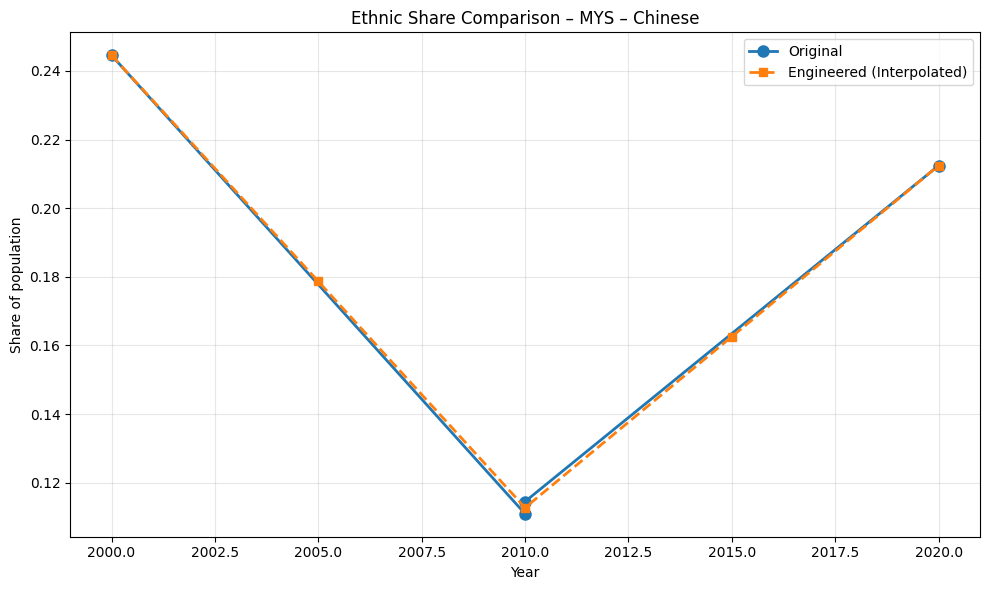

In [ ]:
import matplotlib.pyplot as plt

# ============================
# USER INPUT
# ============================
country_iso = "MYS"                 # change to any iso3 in your dataset
eth_group = "Chinese"               # change to any ethnic_group
# ============================

# --- Filter original (non-interpolated) data ---
orig = ethnic[
    (ethnic["iso3"] == country_iso) &
    (ethnic["ethnic_group"] == eth_group)
][["year", "share"]].sort_values("year")

# --- Filter engineered (interpolated) data ---
eng = engineered[
    (engineered["iso3"] == country_iso) &
    (engineered["ethnic_group"] == eth_group)
][["year", "share_interp"]].sort_values("year")

# --- Plot ---
plt.figure(figsize=(10, 6))

# original datapoints
plt.plot(orig["year"], orig["share"], "o-", label="Original", linewidth=2, markersize=8)

# engineered interpolated curve
plt.plot(eng["year"], eng["share_interp"], "s--", label="Engineered (Interpolated)", linewidth=2, markersize=6)

plt.title(f"Ethnic Share Comparison – {country_iso} – {eth_group}")
plt.xlabel("Year")
plt.ylabel("Share of population")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Forecast 2024

In [ ]:
FORECAST_YEAR = 2024

FORECAST 2024 TOTAL POP PER COUNTRY

In [ ]:
def forecast_pop_2024(df_country):
    iso3 = df_country["iso3"].iloc[0]
    df = (
        df_country[["year", "total_pop"]]
        .drop_duplicates(subset=["year"])
        .sort_values("year")
    )

    years = df["year"].values
    pops = df["total_pop"].values

    if len(df) >= 2:
        # simple linear regression: total_pop ~ year
        coeffs = np.polyfit(years, pops, deg=1)
        slope, intercept = coeffs[0], coeffs[1]
        pred_2024 = slope * FORECAST_YEAR + intercept
    else:
        # fallback: repeat last observation
        pred_2024 = pops[-1]

    pred_2024 = max(pred_2024, 0)  # guard against negative

    return pd.DataFrame({
        "iso3": [iso3],
        "year": [FORECAST_YEAR],
        "total_pop_interp": [pred_2024]
    })

pop_forecast_2024 = (
    totals
    .groupby("iso3", group_keys=False)
    .apply(forecast_pop_2024)
    .reset_index(drop=True)
)

/tmp/ipython-input-2133958146.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast_pop_2024)


FORECAST 2024 SHARES PER COUNTRY–ETHNIC GROUP

In [ ]:
def forecast_share_2024(df_group):
    iso3 = df_group["iso3"].iloc[0]
    group = df_group["ethnic_group"].iloc[0]

    df = (
        df_group[["year", "share"]]
        .drop_duplicates(subset=["year"])
        .sort_values("year")
    )

    years = df["year"].values
    shares = df["share"].values

    if len(df) >= 2:
        coeffs = np.polyfit(years, shares, deg=1)
        slope, intercept = coeffs[0], coeffs[1]
        pred_2024 = slope * FORECAST_YEAR + intercept
    else:
        pred_2024 = shares[-1]  # fallback: repeat last known share

    return pd.DataFrame({
        "iso3": [iso3],
        "ethnic_group": [group],
        "year": [FORECAST_YEAR],
        "share_raw_2024": [pred_2024]
    })

shares_raw_2024 = (
    ethnic_share
    .groupby(["iso3", "ethnic_group"], group_keys=False)
    .apply(forecast_share_2024)
    .reset_index(drop=True)
)

/tmp/ipython-input-3253685492.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(forecast_share_2024)


NORMALISE SHARES IN 2024 TO SUM TO 1 PER COUNTRY (AND CLIP TO [0,1] RANGE)

In [ ]:
def normalise_shares_country(df_country):
    iso3 = df_country["iso3"].iloc[0]

    # clip to [0,1] before normalisation
    df = df_country.copy()
    df["share_clipped"] = df["share_raw_2024"].clip(lower=0, upper=1)

    total = df["share_clipped"].sum()

    if total > 0:
        df["share_interp"] = df["share_clipped"] / total
    else:
        # fallback: if everything collapsed to 0, keep raw values and renormalise
        df["share_interp"] = 1.0 / len(df)

    df["year"] = FORECAST_YEAR
    return df[["iso3", "ethnic_group", "year", "share_interp"]]

share_forecast_2024 = (
    shares_raw_2024
    .groupby("iso3", group_keys=False)
    .apply(normalise_shares_country)
    .reset_index(drop=True)
)

/tmp/ipython-input-3558005568.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(normalise_shares_country)


COMBINE 2024 SHARES + 2024 POP → 2024 VALUES

In [ ]:
engineered_2024 = share_forecast_2024.merge(
    pop_forecast_2024,
    on=["iso3", "year"],
    how="left"
)

engineered_2024["value_interp"] = (
    engineered_2024["share_interp"] * engineered_2024["total_pop_interp"]
).round().astype("Int64")

engineered_2024 = engineered_2024[[
    "iso3", "year", "ethnic_group",
    "value_interp", "share_interp", "total_pop_interp"
]].sort_values(["iso3", "ethnic_group"])

In [ ]:
engineered_2024

,iso3,year,ethnic_group,value_interp,share_interp,total_pop_interp
0,ARG,2024,African,229472,0.005030,4.561879e+07
1,ARG,2024,Indigenous,1306730,0.028645,4.561879e+07
2,ARG,2024,Not Stated,44082585,0.966325,4.561879e+07
3,AUS,2024,Acehnese,141,0.000005,2.584029e+07
4,AUS,2024,Acholi,156,0.000006,2.584029e+07
...,...,...,...,...,...,...
2091,VNM,2024,Thai,1916691,0.018969,1.010407e+08
2092,VNM,2024,Tho,94017,0.000930,1.010407e+08
2093,VNM,2024,Xinh mun,32249,0.000319,1.010407e+08
2094,VNM,2024,Xodan,234164,0.002318,1.010407e+08


## FINAL ENGINEERED DATASET 2000–2020 (INTERPOLATION) + 2024 (FORECAST)

In [ ]:
engineered_full = pd.concat(
    [engineered, engineered_2024],
    ignore_index=True
).sort_values(["iso3", "year", "ethnic_group"])

engineered_full.head()

,iso3,year,ethnic_group,value_interp,share_interp,total_pop_interp
0,ARG,2000,African,229472,0.005030,45618787.0
1,ARG,2000,Indigenous,1306730,0.028645,45618787.0
2,ARG,2000,Not Stated,44082585,0.966325,45618787.0
3,ARG,2005,African,229472,0.005030,45618787.0
4,ARG,2005,Indigenous,1306730,0.028645,45618787.0


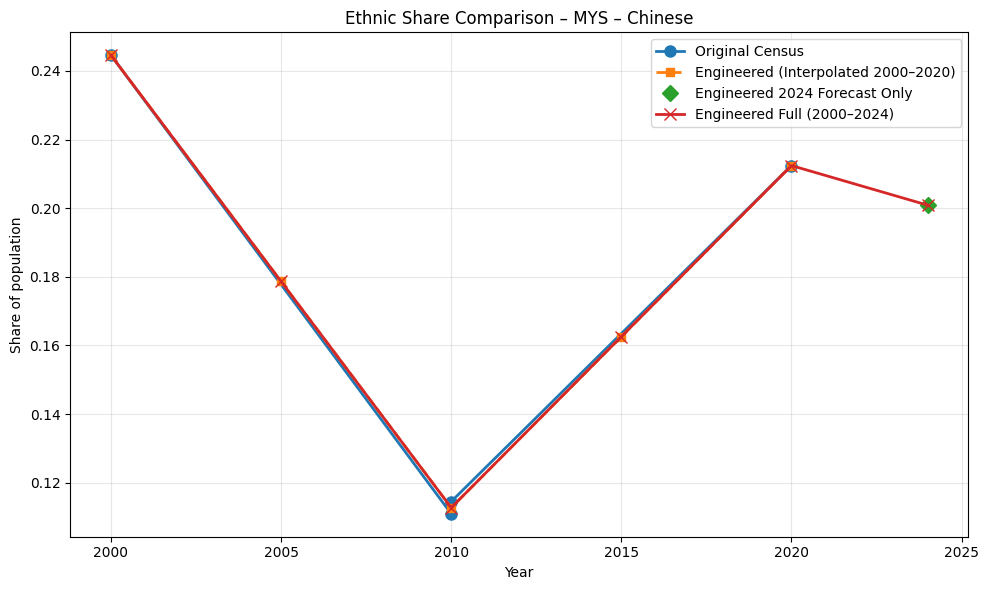

In [ ]:
import matplotlib.pyplot as plt

# ============================
# USER INPUT
# ============================
country_iso = "MYS"                 # change to any iso3 in your dataset
eth_group = "Chinese"               # change to any ethnic_group
# ============================

# --- Filter original (non-interpolated) data ---
orig = ethnic[
    (ethnic["iso3"] == country_iso) &
    (ethnic["ethnic_group"] == eth_group)
][["year", "share"]].sort_values("year")

# --- Filter interpolated 2000–2020 ---
eng_interp = engineered[
    (engineered["iso3"] == country_iso) &
    (engineered["ethnic_group"] == eth_group)
][["year", "share_interp"]].sort_values("year")

# --- Filter 2024 forecast only ---
eng_2024 = engineered_2024[
    (engineered_2024["iso3"] == country_iso) &
    (engineered_2024["ethnic_group"] == eth_group)
][["year", "share_interp"]].sort_values("year")

# --- Filter full dataset (2000–2024) ---
eng_full = engineered_full[
    (engineered_full["iso3"] == country_iso) &
    (engineered_full["ethnic_group"] == eth_group)
][["year", "share_interp"]].sort_values("year")

# --- Plot ---
plt.figure(figsize=(10, 6))

# 1. Original points
plt.plot(orig["year"], orig["share"], "o-",
         label="Original Census", linewidth=2, markersize=8)

# 2. Engineered interpolation
plt.plot(eng_interp["year"], eng_interp["share_interp"], "s--",
         label="Engineered (Interpolated 2000–2020)", linewidth=2, markersize=6)

# 3. Forecast 2024
plt.plot(eng_2024["year"], eng_2024["share_interp"], "D",
         label="Engineered 2024 Forecast Only", markersize=8)

# 4. Full engineered (2000–2024)
plt.plot(eng_full["year"], eng_full["share_interp"], "x-",
         label="Engineered Full (2000–2024)", linewidth=2, markersize=8)

plt.title(f"Ethnic Share Comparison – {country_iso} – {eth_group}")
plt.xlabel("Year")
plt.ylabel("Share of population")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
engineered_full.to_csv("/content/drive/MyDrive/FYP/data/engineered/engineered_ethnic_composition_full.csv", index=False)

# **IMS Dataset**

## Setup

In [ ]:
import pandas as pd
import numpy as np

ims = pd.read_csv("/content/drive/MyDrive/FYP/data/processed/ims_stock_table1_bothsex_countries.csv")
ims.head(), ims.columns

(  iso3_dest destination_raw iso3_orig origin_raw  year         sex   value  \
 0       ABW          Aruba*       CHN      China  1990  Both sexes   247.0   
 1       ABW          Aruba*       CHN      China  1995  Both sexes   435.0   
 2       ABW          Aruba*       CHN      China  2000  Both sexes   622.0   
 3       ABW          Aruba*       CHN      China  2005  Both sexes   855.0   
 4       ABW          Aruba*       CHN      China  2010  Both sexes  1072.0   
 
           metric     unit                          source  
 0  migrant_stock  persons  UNDESA_2024_IMS_Table1_bothsex  
 1  migrant_stock  persons  UNDESA_2024_IMS_Table1_bothsex  
 2  migrant_stock  persons  UNDESA_2024_IMS_Table1_bothsex  
 3  migrant_stock  persons  UNDESA_2024_IMS_Table1_bothsex  
 4  migrant_stock  persons  UNDESA_2024_IMS_Table1_bothsex  ,
 Index(['iso3_dest', 'destination_raw', 'iso3_orig', 'origin_raw', 'year',
        'sex', 'value', 'metric', 'unit', 'source'],
       dtype='object'))

## Engineering

Keep relevant columns only

In [ ]:
ims = ims[[
    "iso3_dest",       # destination ISO3
    "destination_raw", # destination name
    "iso3_orig",       # origin ISO3
    "origin_raw",      # origin name
    "year",
    "value"            # migrant stock
]].copy()

ims

,iso3_dest,destination_raw,iso3_orig,origin_raw,year,value
0,ABW,Aruba*,CHN,China,1990,247.0
1,ABW,Aruba*,CHN,China,1995,435.0
2,ABW,Aruba*,CHN,China,2000,622.0
3,ABW,Aruba*,CHN,China,2005,855.0
4,ABW,Aruba*,CHN,China,2010,1072.0
...,...,...,...,...,...,...
72978,ZWE,Zimbabwe,ZMB,Zambia,2005,29759.0
72979,ZWE,Zimbabwe,ZMB,Zambia,2010,30373.0
72980,ZWE,Zimbabwe,ZMB,Zambia,2015,30538.0
72981,ZWE,Zimbabwe,ZMB,Zambia,2020,31692.0


Keep only modelling years

In [ ]:
TARGET_YEARS = [2000, 2005, 2010, 2015, 2020, 2024]
ims = ims[ims["year"].isin(TARGET_YEARS)].copy()

INFLOW + OUTFLOW filtering logic

In [ ]:
core_iso = ["USA", "MYS", "IDN"]

ims = ims[
    ims["iso3_dest"].isin(core_iso) |
    ims["iso3_orig"].isin(core_iso)
].copy()

ims.sort_values(["iso3_dest", "iso3_orig", "year"], inplace=True)
ims.head()

,iso3_dest,destination_raw,iso3_orig,origin_raw,year,value
146,ABW,Aruba*,USA,United States of America*,2000,681.0
147,ABW,Aruba*,USA,United States of America*,2005,638.0
148,ABW,Aruba*,USA,United States of America*,2010,583.0
149,ABW,Aruba*,USA,United States of America*,2015,612.0
150,ABW,Aruba*,USA,United States of America*,2020,683.0


In [ ]:
ims_od = (
    ims.groupby(["iso3_orig", "iso3_dest", "year"], as_index=False)["value"]
       .sum()
       .rename(columns={"value": "migrant_stock"})
)

,iso3_orig,iso3_dest,year,migrant_stock
0,AFG,IDN,2000,78.0
1,AFG,IDN,2005,36.0
2,AFG,IDN,2010,1548.0
3,AFG,IDN,2015,6263.0
4,AFG,IDN,2020,7646.0


In [ ]:
ims_od

,iso3_orig,iso3_dest,year,migrant_stock
0,AFG,IDN,2000,78.0
1,AFG,IDN,2005,36.0
2,AFG,IDN,2010,1548.0
3,AFG,IDN,2015,6263.0
4,AFG,IDN,2020,7646.0
...,...,...,...,...
2227,YEM,MYS,2005,0.0
2228,YEM,MYS,2010,18.0
2229,YEM,MYS,2015,654.0
2230,YEM,MYS,2020,3662.0


Compute destination and origin totals

In [ ]:
ims_dest_totals = (
    ims_od
    .groupby(["iso3_dest", "year"], as_index=False)["migrant_stock"]
    .sum()
    .rename(columns={"migrant_stock": "dest_total_migrant_stock"})
)

In [ ]:
ims_orig_totals = (
    ims_od
    .groupby(["iso3_orig", "year"], as_index=False)["migrant_stock"]
    .sum()
    .rename(columns={"migrant_stock": "orig_total_migrant_stock"})
)

## Checkpoint

In [ ]:
ims_engineered = ims_od.copy()

# Merge inflow side
ims_engineered = ims_engineered.merge(
    ims_dest_totals, on=["iso3_dest", "year"], how="left"
)

# Merge outflow side
ims_engineered = ims_engineered.merge(
    ims_orig_totals, on=["iso3_orig", "year"], how="left"
)

# Compute shares
ims_engineered["origin_share_in_dest_migrants"] = (
    ims_engineered["migrant_stock"] / ims_engineered["dest_total_migrant_stock"]
)

ims_engineered["dest_share_of_origin_emigration"] = (
    ims_engineered["migrant_stock"] / ims_engineered["orig_total_migrant_stock"]
)

In [ ]:
ims_engineered.head()

,iso3_orig,iso3_dest,year,migrant_stock,dest_total_migrant_stock,orig_total_migrant_stock,origin_share_in_dest_migrants,dest_share_of_origin_emigration
0,AFG,IDN,2000,78.0,280446.0,41817.0,0.000278,0.001865
1,AFG,IDN,2005,36.0,95078.0,56537.0,0.000379,0.000637
2,AFG,IDN,2010,1548.0,100661.0,60781.0,0.015378,0.025468
3,AFG,IDN,2015,6263.0,135695.0,86729.0,0.046155,0.072213
4,AFG,IDN,2020,7646.0,292106.0,145672.0,0.026175,0.052488


## Seperation (Destination only and Origin only)

In [ ]:
def hhi(series):
    s = series.dropna()
    return (s ** 2).sum() if len(s) else np.nan

ims_destination_features = (
    ims_engineered[ims_engineered["iso3_dest"].isin(core_iso)]
    .groupby(["iso3_dest", "year"], as_index=False)
    .agg(
        dest_total_migrant_stock=("dest_total_migrant_stock", "first"),
        n_origins=("iso3_orig", "nunique"),
        origin_hhi=("origin_share_in_dest_migrants", hhi)
    )
    .rename(columns={"iso3_dest": "iso3"})
)

ims_destination_features.head()

,iso3,year,dest_total_migrant_stock,n_origins,origin_hhi
0,IDN,2000,280446.0,27,0.451204
1,IDN,2005,95078.0,27,0.177691
2,IDN,2010,100661.0,27,0.176242
3,IDN,2015,135695.0,27,0.188606
4,IDN,2020,292106.0,27,0.220246


In [ ]:
ims_origin_features = (
    ims_engineered[ims_engineered["iso3_orig"].isin(core_iso)]
    .groupby(["iso3_orig", "year"], as_index=False)
    .agg(
        orig_total_migrant_stock=("orig_total_migrant_stock", "first"),
        n_destinations=("iso3_dest", "nunique"),
        destination_hhi=("dest_share_of_origin_emigration", hhi)
    )
    .rename(columns={"iso3_orig": "iso3"})
)

ims_origin_features.head()

,iso3,year,orig_total_migrant_stock,n_destinations,destination_hhi
0,IDN,2000,2248113.0,63,0.191025
1,IDN,2005,2535440.0,63,0.233477
2,IDN,2010,3182777.0,63,0.260020
3,IDN,2015,3434177.0,63,0.245428
4,IDN,2020,3647140.0,63,0.242806


In [ ]:
ims_engineered.to_csv("/content/drive/MyDrive/FYP/data/engineered/ims_od_inflow_outflow_engineered.csv", index=False)
ims_destination_features.to_csv("/content/drive/MyDrive/FYP/data/engineered/ims_destination_features.csv", index=False)
ims_origin_features.to_csv("/content/drive/MyDrive/FYP/data/engineered/ims_origin_features.csv", index=False)

# **GDELT**

## Setup

In [ ]:
!pip install pycountry

import pandas as pd
import numpy as np
import pycountry

In [ ]:
gdelt = pd.read_csv("/content/drive/MyDrive/FYP/data/processed/gdelt_country_year_category.csv")
gdelt.head(), gdelt.columns, gdelt.dtypes

(  country  year              category  event_count  goldstein_avg  tone_avg
 0      AF  1996       Aid/Cooperation        11059          3.429     5.219
 1      AF  1996    Conflict/Migration         4606         -9.875     3.322
 2      AF  1996  Disapproval/Sanction         2269         -3.150     4.703
 3      AF  1996                 Other         9605          2.027     4.869
 4      AF  1996               Protest          473         -5.585     4.402,
 Index(['country', 'year', 'category', 'event_count', 'goldstein_avg',
        'tone_avg'],
       dtype='object'),
 country           object
 year               int64
 category          object
 event_count        int64
 goldstein_avg    float64
 tone_avg         float64
 dtype: object)

validation checks

In [ ]:
# 1. Year range
print("Year range:", gdelt["year"].min(), "→", gdelt["year"].max())

# 2. Few random rows for sanity
print("\nSample rows:")
display(gdelt.sample(10))

# 3. Nulls per column
print("\nMissing values per column:")
print(gdelt.isna().sum())

# 4. Unique categories
print("\nExample categories:")
print(gdelt["category"].dropna().unique()[:20])

# 5. Countries sample
print("\nCountry codes:")
print(gdelt["country"].dropna().unique())

Year range: 1996 → 2024

Sample rows:


,country,year,category,event_count,goldstein_avg,tone_avg
1131,CN,2019,Conflict/Migration,88,-9.915,-5.578
4097,KE,2004,Other,40728,1.524,5.234
362,AU,2010,Disapproval/Sanction,3467,-2.958,5.211
2746,GH,2024,Disapproval/Sanction,34556,-2.856,-2.004
1967,ER,2013,Other,4238,1.550,2.303
6577,SO,2010,Aid/Cooperation,26433,3.028,5.086
5280,NZ,2010,Conflict/Migration,7783,-9.792,4.937
6615,SO,2017,Other,80235,1.709,-4.126
6518,SO,1998,Conflict/Migration,1335,-9.760,3.942
5781,PK,2023,Disapproval/Sanction,87305,-2.948,-4.176



Missing values per column:
country          0
year             0
category         0
event_count      0
goldstein_avg    0
tone_avg         0
dtype: int64

Example categories:
['Aid/Cooperation' 'Conflict/Migration' 'Disapproval/Sanction' 'Other'
 'Protest']

Country codes:
['AF' 'AR' 'AU' 'BD' 'BN' 'BR' 'CA' 'CN' 'CO' 'CU' 'DO' 'EC' 'EG' 'ER'
 'ES' 'ET' 'FR' 'GB' 'GH' 'GR' 'GT' 'GY' 'HK' 'ID' 'IN' 'IR' 'IT' 'JM'
 'KE' 'KR' 'LA' 'MX' 'MY' 'NG' 'NI' 'NP' 'NZ' 'PA' 'PE' 'PK' 'PL' 'PS'
 'RO' 'SA' 'SG' 'SO' 'SV' 'SY' 'TH' 'TL' 'TT' 'US' 'VE']


## Engineering

iso2 -> iso3 using pycountry

In [ ]:
def iso2_to_iso3_safe(alpha2):
    try:
        return pycountry.countries.get(alpha_2=str(alpha2)).alpha_3
    except:
        return None

gdelt["iso3"] = gdelt["country"].apply(iso2_to_iso3_safe)

print("Rows before ISO3 filter:", len(gdelt))
gdelt = gdelt[gdelt["iso3"].isin(needed_iso3)].copy()
print("Rows after ISO3 filter:", len(gdelt))

gdelt.head()

Rows before ISO3 filter: 7603
Rows after ISO3 filter: 7603


,country,year,category,event_count,goldstein_avg,tone_avg,iso3
0,AF,1996,Aid/Cooperation,11059,3.429,5.219,AFG
1,AF,1996,Conflict/Migration,4606,-9.875,3.322,AFG
2,AF,1996,Disapproval/Sanction,2269,-3.150,4.703,AFG
3,AF,1996,Other,9605,2.027,4.869,AFG
4,AF,1996,Protest,473,-5.585,4.402,AFG


Hybrid windows (geopolitics leading up to migration year):

*  1996–2000 → 2000
*  2001–2005 → 2005
*  2006–2010 → 2010
*  2011–2015 → 2015
*  2016–2020 → 2020
*  2021–2024 → 2024


In [ ]:
def map_year_to_window_hybrid(y):
    if 1996 <= y <= 2000:
        return 2000
    elif 2001 <= y <= 2005:
        return 2005
    elif 2006 <= y <= 2010:
        return 2010
    elif 2011 <= y <= 2015:
        return 2015
    elif 2016 <= y <= 2020:
        return 2020
    elif 2021 <= y <= 2024:
        return 2024
    else:
        return None  # outside scope

gdelt["year_window"] = gdelt["year"].apply(map_year_to_window_hybrid)

TARGET_WINDOWS = [2000, 2005, 2010, 2015, 2020, 2024]

print("Rows before window filter:", len(gdelt))
gdelt = gdelt[gdelt["year_window"].isin(TARGET_WINDOWS)].copy()
print("Rows after window filter:", len(gdelt))

gdelt[["year", "year_window"]].drop_duplicates().sort_values(["year_window", "year"]).head(20)


Rows before window filter: 7603
Rows after window filter: 7603


,year,year_window
0,1996,2000
5,1997,2000
10,1998,2000
15,1999,2000
20,2000,2000
25,2001,2005
30,2002,2005
35,2003,2005
40,2004,2005
45,2005,2005


In [ ]:
gdelt

,country,year,category,event_count,goldstein_avg,tone_avg,iso3,year_window
0,AF,1996,Aid/Cooperation,11059,3.429,5.219,AFG,2000
1,AF,1996,Conflict/Migration,4606,-9.875,3.322,AFG,2000
2,AF,1996,Disapproval/Sanction,2269,-3.150,4.703,AFG,2000
3,AF,1996,Other,9605,2.027,4.869,AFG,2000
4,AF,1996,Protest,473,-5.585,4.402,AFG,2000
...,...,...,...,...,...,...,...,...
7598,VE,2024,Aid/Cooperation,30115,2.993,-2.253,VEN,2024
7599,VE,2024,Conflict/Migration,8190,-9.757,-6.619,VEN,2024
7600,VE,2024,Disapproval/Sanction,15150,-2.835,-5.013,VEN,2024
7601,VE,2024,Other,51884,0.552,-4.098,VEN,2024


## Checkpoint

Aggregate to country–window–category

In [ ]:
def weighted_mean(values, weights):
    v = np.array(values, dtype=float)
    w = np.array(weights, dtype=float)
    if w.sum() == 0:
        return np.nan
    return (v * w).sum() / w.sum()

group_cols = ["iso3", "year_window", "category"]

gdelt_country_window_category = (
    gdelt
    .groupby(group_cols, as_index=False)
    .agg(
        total_event_count=("event_count", "sum"),
        goldstein_wavg=("goldstein_avg", lambda x: weighted_mean(x, gdelt.loc[x.index, "event_count"])),
        tone_wavg=("tone_avg", lambda x: weighted_mean(x, gdelt.loc[x.index, "event_count"]))
    )
)

gdelt_country_window_category.head()


,iso3,year_window,category,total_event_count,goldstein_wavg,tone_wavg
0,AFG,2000,Aid/Cooperation,55838,3.350280,5.273762
1,AFG,2000,Conflict/Migration,22923,-9.875108,3.737414
2,AFG,2000,Disapproval/Sanction,13241,-3.038943,4.864997
3,AFG,2000,Other,56331,1.612153,4.964630
4,AFG,2000,Protest,2308,-5.436750,4.763665


Pivot to wide format per country–window

In [ ]:
# 1) Event counts
event_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="total_event_count",
    aggfunc="sum",
    fill_value=0
)

# 2) Goldstein (weighted average)
goldstein_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="goldstein_wavg",
    aggfunc="mean"
)

# 3) Tone (weighted average)
tone_pivot = gdelt_country_window_category.pivot_table(
    index=["iso3", "year_window"],
    columns="category",
    values="tone_wavg",
    aggfunc="mean"
)

# Flatten column names
event_pivot.columns = [f"gdelt_events_{str(c).replace(' ', '_')}" for c in event_pivot.columns]
goldstein_pivot.columns = [f"gdelt_goldstein_{str(c).replace(' ', '_')}" for c in goldstein_pivot.columns]
tone_pivot.columns = [f"gdelt_tone_{str(c).replace(' ', '_')}" for c in tone_pivot.columns]

gdelt_country_window_wide = (
    event_pivot
    .join(goldstein_pivot)
    .join(tone_pivot)
    .reset_index()
    .rename(columns={"year_window": "year"})
    .sort_values(["iso3", "year"])
)

gdelt_country_window_wide.head()


,iso3,year,gdelt_events_Aid/Cooperation,gdelt_events_Conflict/Migration,gdelt_events_Disapproval/Sanction,gdelt_events_Other,gdelt_events_Protest,gdelt_goldstein_Aid/Cooperation,gdelt_goldstein_Conflict/Migration,gdelt_goldstein_Disapproval/Sanction,gdelt_goldstein_Other,gdelt_goldstein_Protest,gdelt_tone_Aid/Cooperation,gdelt_tone_Conflict/Migration,gdelt_tone_Disapproval/Sanction,gdelt_tone_Other,gdelt_tone_Protest
0,AFG,2000,55838,22923,13241,56331,2308,3.350280,-9.875108,-3.038943,1.612153,-5.436750,5.273762,3.737414,4.864997,4.964630,4.763665
1,AFG,2005,193939,79069,47640,239453,8807,3.006666,-9.875837,-2.914877,1.544497,-5.479002,5.484456,3.662321,4.971895,5.072714,5.049306
2,AFG,2010,461064,420476,167877,751875,33370,3.030422,-9.883702,-2.843986,1.740744,-5.347443,5.300836,3.375194,4.586475,4.814998,4.715401
3,AFG,2015,762060,528236,230956,1009718,42438,3.225562,-9.896336,-2.850445,1.815015,-5.380908,2.526510,0.685107,1.365453,1.848111,1.279910
4,AFG,2020,762290,493176,242649,979555,43507,3.242147,-9.883673,-2.892414,1.846640,-5.328078,-1.801405,-6.310942,-4.414519,-3.386740,-4.638625


subset for USA, MYS, IDN

In [ ]:
core_iso = ["USA", "MYS", "IDN"]

gdelt_core = gdelt_country_window_wide[
    gdelt_country_window_wide["iso3"].isin(core_iso)
].copy()

gdelt_core.head()

,iso3,year,gdelt_events_Aid/Cooperation,gdelt_events_Conflict/Migration,gdelt_events_Disapproval/Sanction,gdelt_events_Other,gdelt_events_Protest,gdelt_goldstein_Aid/Cooperation,gdelt_goldstein_Conflict/Migration,gdelt_goldstein_Disapproval/Sanction,gdelt_goldstein_Other,gdelt_goldstein_Protest,gdelt_tone_Aid/Cooperation,gdelt_tone_Conflict/Migration,gdelt_tone_Disapproval/Sanction,gdelt_tone_Other,gdelt_tone_Protest
138,IDN,2000,89466,30579,31558,137164,4955,3.013236,-9.830729,-3.088143,0.963541,-5.135121,5.150253,3.403388,4.835819,4.751689,4.595396
139,IDN,2005,87303,33510,34380,143083,5679,3.024398,-9.874122,-2.867814,0.613506,-5.453518,5.098430,3.413985,4.496457,4.531498,4.523846
140,IDN,2010,179779,41504,54285,292485,7983,3.030996,-9.868301,-2.966652,1.066279,-5.221890,5.428803,3.811111,4.778465,4.845015,4.516204
141,IDN,2015,430418,75507,118862,638661,16149,3.007119,-9.838508,-3.053250,1.249606,-5.057590,2.343627,0.678656,1.500458,1.702471,1.067650
142,IDN,2020,471575,87005,117140,660724,19019,2.955381,-9.803545,-2.997991,1.220772,-5.117506,-0.761177,-5.625560,-3.399503,-2.427402,-4.293444


Save engineered outputs

In [ ]:
gdelt_country_window_category.to_csv("/content/drive/MyDrive/FYP/data/engineered/gdelt_country_window_category_long.csv", index=False)
gdelt_country_window_wide.to_csv("/content/drive/MyDrive/FYP/data/engineered/gdelt_country_window_wide_hybridwindows.csv", index=False)
gdelt_core.to_csv("/content/drive/MyDrive/FYP/data/engineered/gdelt_core_usa_mys_idn_hybridwindows.csv", index=False)